# Study the Kr response per PMT

JAH 1/05/2025

### imports

In [4]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [5]:
import os

import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [6]:
import ipywidgets as widgets
from IPython.display import display

In [7]:
import os
import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [85]:
import hipy.utils        as ut
import hipy.pltext       as pltext
import hipy.profile      as prof
import hipy.styles       as pltsty

pltsty.style('jhep')

In [9]:
from invisible_cities.io  . pmaps_io        import load_pmaps, load_pmaps_as_df
from invisible_cities.core.core_functions import in_range

### configuration

### load data

In [10]:
run, version = 15269, "v2.3.1/20250429" # run at LSC 250502 v2.3.1/20250429
run, version = 15332, "v2.3.1/20250512" # pure Kr - castle semi-close
path_data = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/data"
path_run  =  f"/{run}/hdf5/prod/{version}/irene/trigger1/ldc1"

In [11]:
path = path_data + path_run
#path = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/15269/hdf5/prod/v2.3.1/20250429/irene/trigger1/ldc1"
filenames = os.listdir(path)
filenames = [os.path.join(path, f) for f in filenames]
#for f in filenames: print(f)

### Ana

In [12]:
## reading as DF
from collections import namedtuple

# Definimos el tipo
pmap_names = ['s1', 's2', 'si', 's1_pmt', 's2_pmt']
PMap       = namedtuple('PMap', pmap_names)

# Creamos una instancia
#electron = Particula(nombre='electrón', masa=9.11e-31, carga=-1.6e-19)

pmap = PMap(*load_pmaps_as_df(filenames[0]))

def pmap_save(pmap, filename):
    for name, df in zip(pmap_names, pmap):
        df.to_hdf(filename, key = name, mode = 'a', complevel = 9, complib = 'blosc')


def pmap_load(filename):
    pmap = PMap(*[pd.read_hdf(filename, key = name) for name in pmap_names])
    return pmap


In [13]:
kdst = pd.read_hdf(f"kdst_lowene_{run}.h5", key='kdst')
kdst_events = kdst.event.unique()
nevents     = len(kdst_events)
print(f'Total number of events in kds {nevents}')

Total number of events in kds 251293


In [14]:
kdst

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Zrms,X,Y,R,Phi,Xrms,Yrms,d2band,abs_d2band,DTguess
1,673199,1.747850e+09,1,0,2,1,275.0,2.111424,14.790461,443050.0,...,5.587833,-207.212544,-69.170850,47721.644756,-2.819408,15.361260,15.827621,-1.785488,1.785488,908.937420
2,673206,1.747850e+09,0,0,1,1,275.0,0.895769,7.186266,1228600.0,...,2.359195,390.856575,-56.558274,155967.700758,-0.143706,12.752070,12.907962,-0.733796,0.733796,154.288276
7,673227,1.747850e+09,1,0,18,1,225.0,3.447129,18.330517,669175.0,...,5.053157,-321.878855,-188.525491,139147.858032,-2.611752,14.561559,15.258464,0.213941,0.213941,741.599940
24,673234,1.747850e+09,0,0,1,1,225.0,1.159202,6.807552,1196525.0,...,2.649375,413.866334,-187.318858,206373.696783,-0.425020,13.626606,13.357302,-0.303228,0.303228,197.034900
33,673255,1.747850e+09,5,0,6,1,125.0,0.854236,2.777985,1237400.0,...,2.438437,-195.975927,345.834783,158008.261071,2.086352,12.317063,14.300072,-0.055377,0.055377,165.469890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
908487,2236705,1.747888e+09,0,0,2,1,125.0,3.431521,12.782838,351575.0,...,5.800062,214.918234,-104.341606,57077.017944,-0.451976,16.753003,15.651366,-2.579944,2.579944,980.021157
908489,2236712,1.747888e+09,0,0,2,1,225.0,2.261131,13.273375,405575.0,...,5.790284,-75.511360,-269.329635,78240.417677,-1.844146,14.610168,14.069806,-0.687714,0.687714,976.687801
908500,2236726,1.747888e+09,5,0,6,1,225.0,2.248276,9.560928,1179525.0,...,2.758405,-434.662469,-162.573252,215361.524479,-2.783680,12.262482,10.640492,-0.325896,0.325896,214.376460
908503,2236747,1.747888e+09,0,0,1,1,375.0,2.270540,13.761021,205725.0,...,6.272414,222.055084,-24.889544,49927.949667,-0.111621,16.624249,17.930007,-1.768218,1.768218,1147.740534


In [15]:
def run_(filenames, ofilename = f"pmap_lowene_{run}.h5", nfiles = -1):

    nfiles = len(filenames) if nfiles == -1 else nfiles
    progress_bar  = widgets.IntProgress(value = 0, min = 0, max = nfiles - 1, description = 'processing:')
    display(progress_bar)

    def _sel(df):
        return np.isin(df.event, kdst_events)

    nsize = 0
    pmaps = [[], [], [], [], []]
    for i, file in enumerate(filenames[:nfiles]):
        progress_bar.value = i
        kpmap  = load_pmaps_as_df(file)
        sel    = _sel(kpmap[0])
        kevts  = len(kpmap[0][sel].event.unique())
        if (kevts <= 0): continue
        for j, df in enumerate(kpmap): pmaps[j].append(df[_sel(df)])
        nsize += kevts

    print('preparing DFs')
    pmap = [pd.concat(dfs) for dfs in pmaps]
    #print('file ', i, ' pmap  selected events ', len(pmap [0]     .event.unique()))
    pmap = [df.sort_values(by="event").reset_index(drop=True) for df in pmap]

    print('number of saved events   ', nsize)
    print('number of events in pmap ', len(pmap[0].event.unique()))
    ns = [len(df.event.unique()) for df in pmap]
    print(f'Check : number of events in the different PMap dsts: {ns}')

    pmap = PMap(*pmap)
    pmap_save(pmap, ofilename)

    return pmap


In [16]:
dorun = False
nfiles = 100
if (dorun):
    pmap = run_(filenames, nfiles = nfiles)
    ns = [len(df.event.unique()) for df in pmap]
    print(f'Check : number of events in the different PMap dsts: {ns}')
    pmap = PMap(*pmap)
    pmap_save(pmap, f"pmap_lowene_{run}.h5")

## read the data

In [17]:
#pmap = PMap(*pmap)
pmap = pmap_load(f"pmap_lowene_{run}.h5");

In [18]:
ns = [len(df.event.unique()) for df in pmap]
print(f'Check : number of events in the different PMap dsts: {ns}')

Check : number of events in the different PMap dsts: [12599, 12599, 12599, 12599, 12599]


In [19]:
s1count  = pmap.s1.groupby("event").count()
s1sum    = pmap.s1.groupby("event").sum()
s2sum    = pmap.s2.groupby("event").sum()
sisum    = pmap.si.groupby("event").sum()

In [20]:
pmap.s1.groupby("event").count();

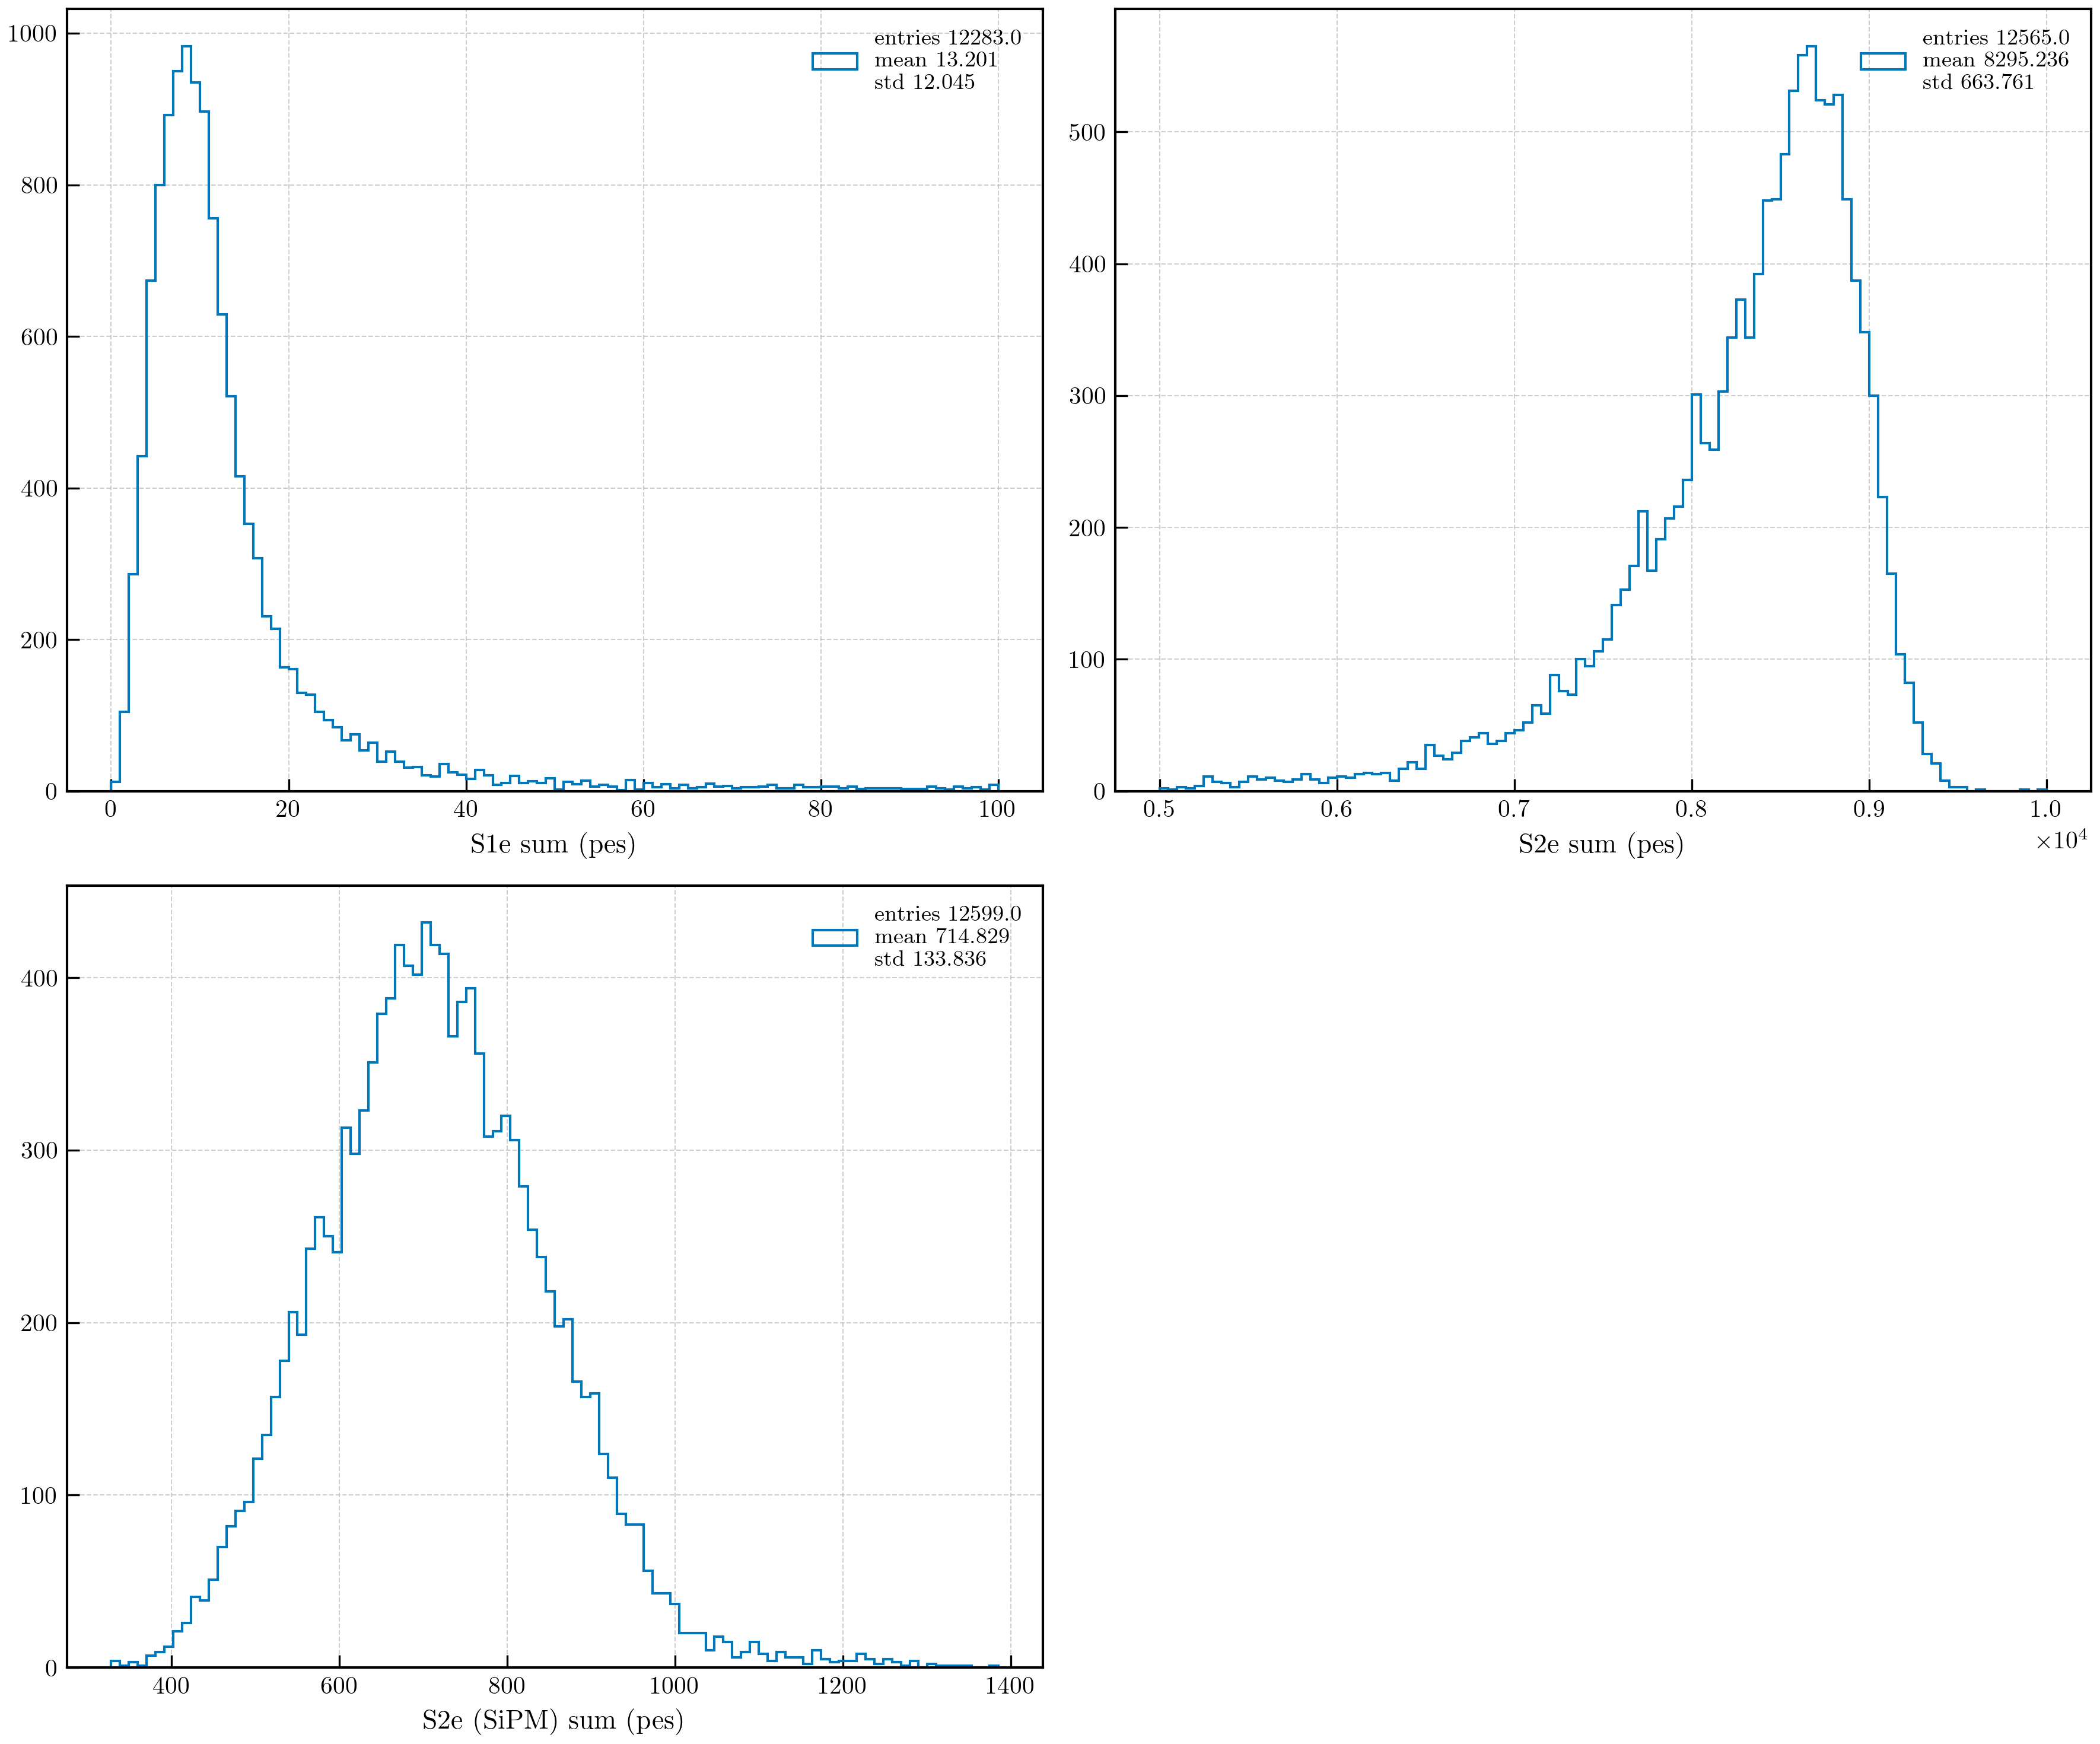

In [86]:
cv = pltext.canvas(4, 2)

cv(1); pltext.hist(s1sum.ene, 100, (0, 100)); plt.xlabel("S1e sum (pes)")
cv(2); pltext.hist(s2sum.ene, 100, (5e3, 10e3)); plt.xlabel("S2e sum (pes)")
cv(3); pltext.hist(sisum.ene, 100); plt.xlabel("S2e (SiPM) sum (pes)");
plt.tight_layout()

In [23]:
pmap.s1_pmt

,event,peak,npmt,ene
0,66761,0,0,-0.000328
1,66761,1,18,0.001242
2,66761,1,18,-0.027327
3,66761,1,18,0.001242
4,66761,1,18,0.001242
...,...,...,...,...
12133291,2760410,0,16,-0.107477
12133292,2760410,0,16,-0.107477
12133293,2760410,0,16,-0.061956
12133294,2760410,0,26,0.053805


In [24]:
df   = pmap.s2_pmt
pmtsum = df.groupby("event npmt".split())['ene'].sum()

In [25]:
pmtsum

event    npmt
66761    0       146.469070
         1       354.282227
         2       184.786362
         4       160.292786
         5       143.316681
                    ...    
2760410  54      224.972748
         55      109.889038
         56      120.302307
         57      149.564911
         59      171.581253
Name: ene, Length: 604752, dtype: float32

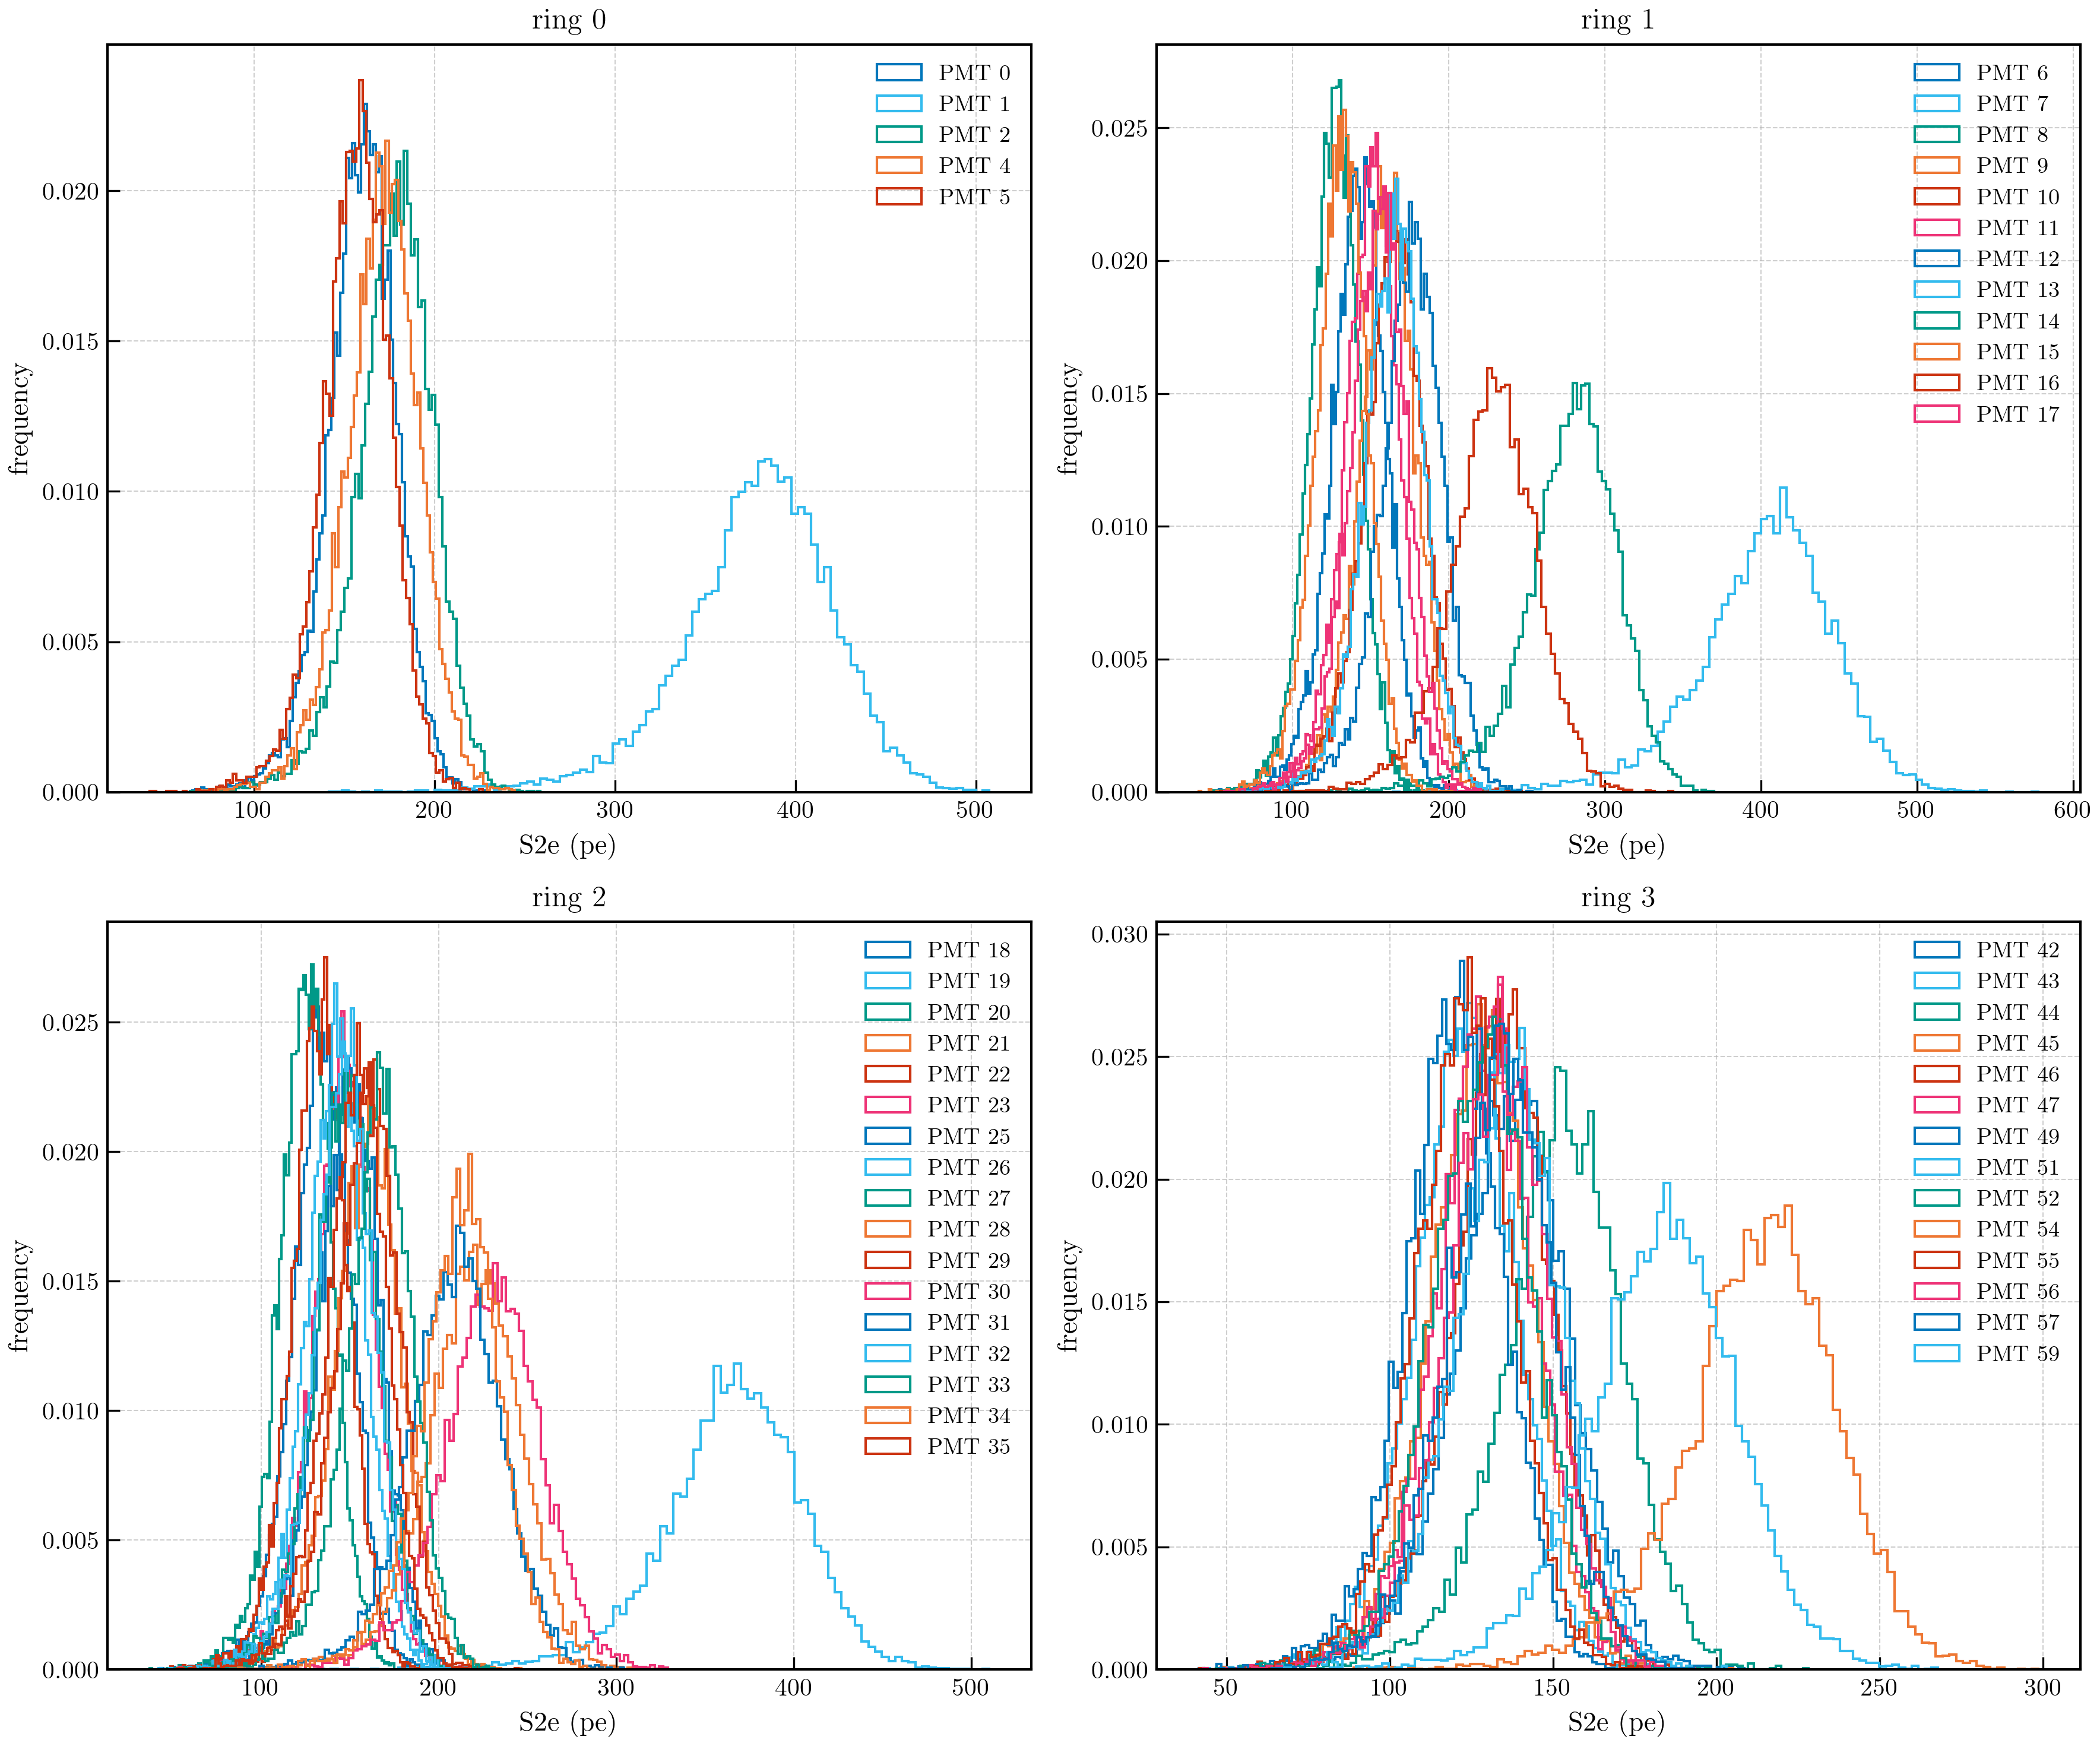

In [87]:
df   = pmap.s2_pmt
pmtsum = df.groupby("event npmt".split())['ene'].sum()

npmts = 60
pmt_index = df.npmt.unique()
pmt_rings = [np.arange(0, 6), np.arange(6, 18), np.arange(18, 36), np.arange(36, 60)]
cv = pltext.canvas(4, 2)
pmt_mean, pmt_std = np.zeros(npmts), np.zeros(npmts)
for k, ids in enumerate(pmt_rings):
    cv(k+1)
    for i in ids:
        if i not in pmt_index: continue
        ipmt_s2 = pmtsum.xs(i, level = "npmt")
        pmt_mean[i] = np.mean(ipmt_s2); pmt_std[i] = np.std(ipmt_s2)
        pltext.hist(ipmt_s2, 100, density = True, stats = False, label = f"PMT {i}"); plt.xlabel("S2e (pe)");
    plt.title(f"ring {k}"); plt.ylabel("frequency");
plt.tight_layout()

In [111]:
pmt_std

array([19.37420273, 41.67250443, 21.53418159,  0.        , 21.01068687,
       19.31217194, 18.10271835, 43.52906418, 16.06100273, 19.47253609,
       20.20425797, 18.16529846, 20.79676819, 19.87892342, 30.02024269,
       17.13075066, 28.12627029, 19.22874641, 17.40670776, 39.45082855,
       15.76125431, 20.48645973, 16.51532364, 18.0033474 ,  0.        ,
       18.45214081, 17.79833031, 18.66997719, 26.84316635, 19.09620476,
       28.58475304, 26.54592514, 18.21216774, 19.57592773, 23.90703201,
       18.46318817,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , 17.88911247, 15.95380306, 18.68451118,
       16.06949615, 16.22533989, 15.92099285,  0.        , 15.48679733,
        0.        , 17.15550804, 16.37045479,  0.        , 23.91332054,
       15.40876389, 16.56544685, 16.6938858 ,  0.        , 23.04290009])

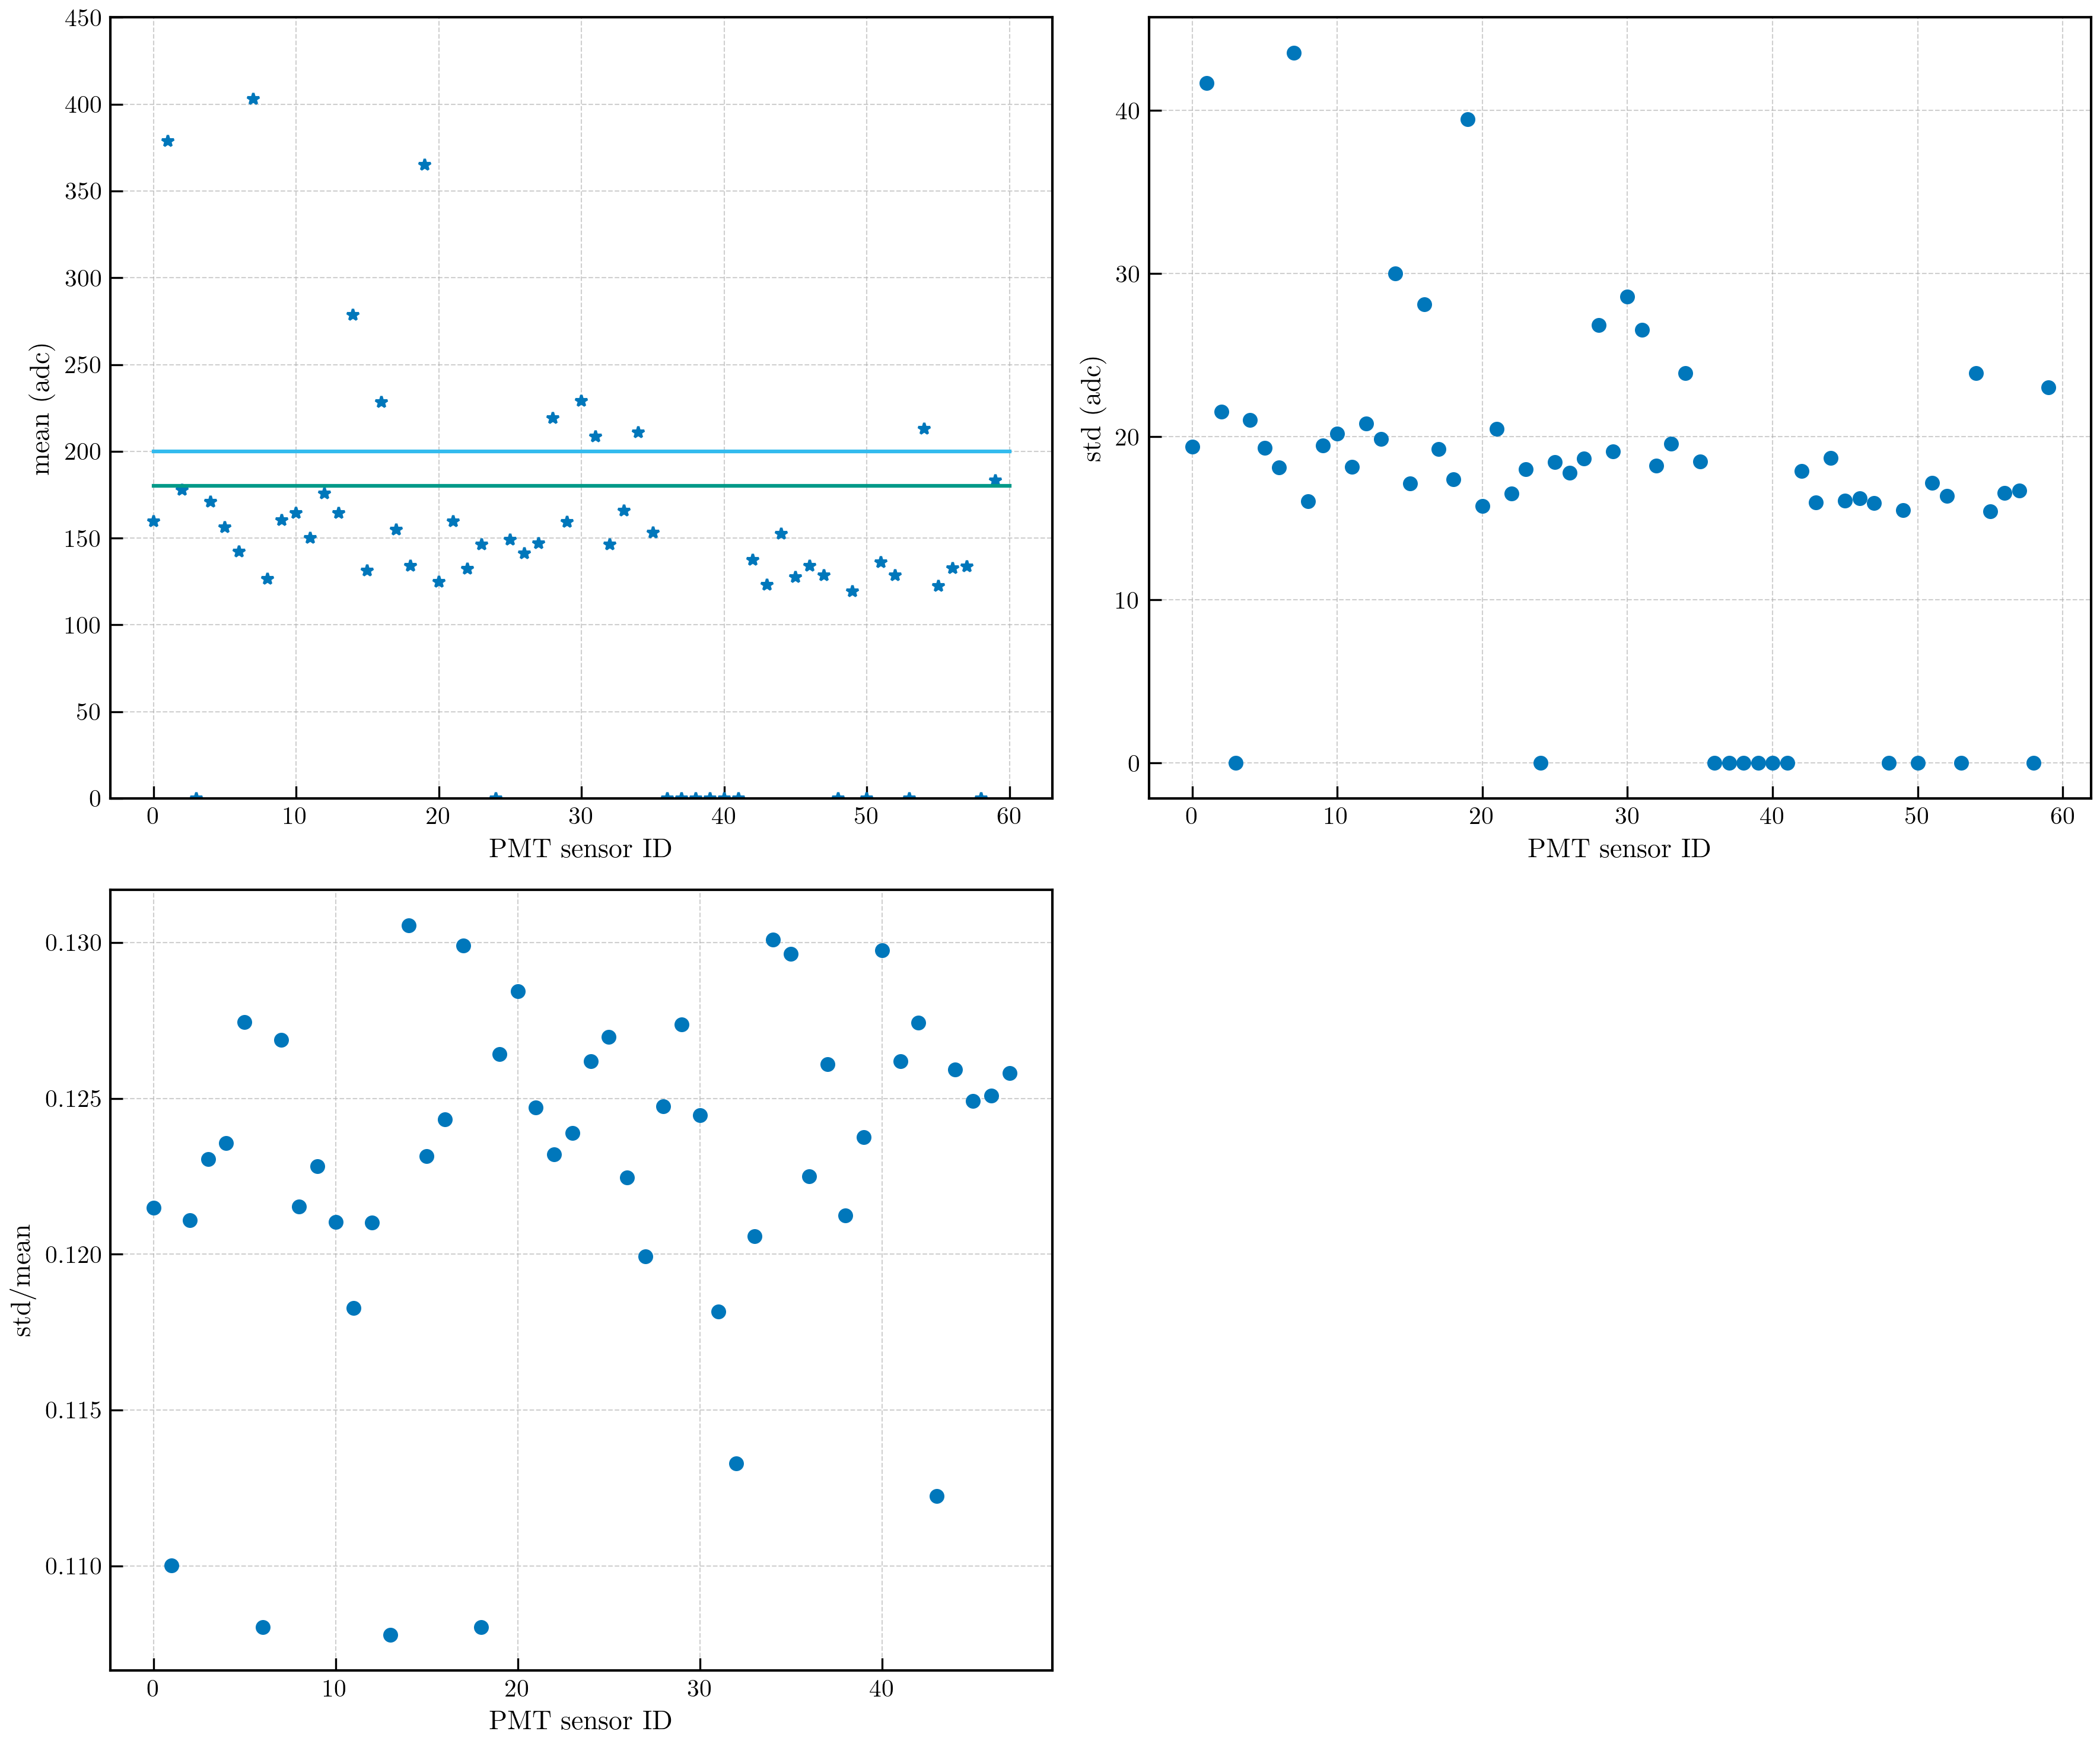

In [115]:
cv = pltext.canvas(4, 2);
cv(1); plt.plot(pmt_mean, '*', label = 'gain');  
plt.xlabel('PMT sensor ID'); plt.ylabel('mean (adc)');
plt.ylim(0, 450); plt.plot((0, 60), (200., 200)); plt.plot((0, 60), (180., 180));
cv(2); plt.plot(pmt_std, 'o', label = 'sigma');
plt.xlabel('PMT sensor ID'); plt.ylabel('std (adc)');
pmt_on = pmt_std > 0
cv(3);  plt.plot(pmt_std[pmt_on]/pmt_mean[pmt_on], 'o'); 
plt.xlabel('PMT sensor ID'); plt.ylabel('std/mean');
#cv(3); pltext.hist(pmt_mean[pmt_on], 40); plt.xlabel('PMT sensor ID'); plt.ylabel('S2e Kr'); 
#cv(4); pltext.hist(pmt_std[pmt_on], 40); plt.xlabel('PMT sensor ID'); plt.ylabel('S2e std Kr'); 
plt.tight_layout()


In [ ]:
# Create a figure and axis
plt.figure()
plt.scatter(X, Y, color='blue')  # Plot the points

# Loop over each index i
for i in range(len(X)):
    plt.text(X[i], Y[i], str(i), fontsize=12, ha='center', va='bottom')  # Annotate with index i

# Add labels and title
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')
plt.title('Plot position of PMTs')
plt.grid(True)

# Show the plot
plt.show()

In [91]:
pmt_ok = in_range(pmt_mean, 1, 180)
pmt_mean_ring = np.zeros(4)
for i, ids in enumerate(pmt_rings):
    nn, mm = 0, 0
    for id in ids:
        if (pmt_ok[id]):
            nn+=1; mm += pmt_mean[id]
    pmt_mean_ring[i] = mm/nn
print(pmt_mean_ring)
pmt_gain_in_ring = np.ones(60)
for i, ids in enumerate(pmt_rings):
    for id in ids:
        if (pmt_mean[id] > 0 ): pmt_gain_in_ring[id] = pmt_mean_ring[i]/pmt_mean[id]
    

[166.08013153 152.15395186 146.50758044 131.26851908]


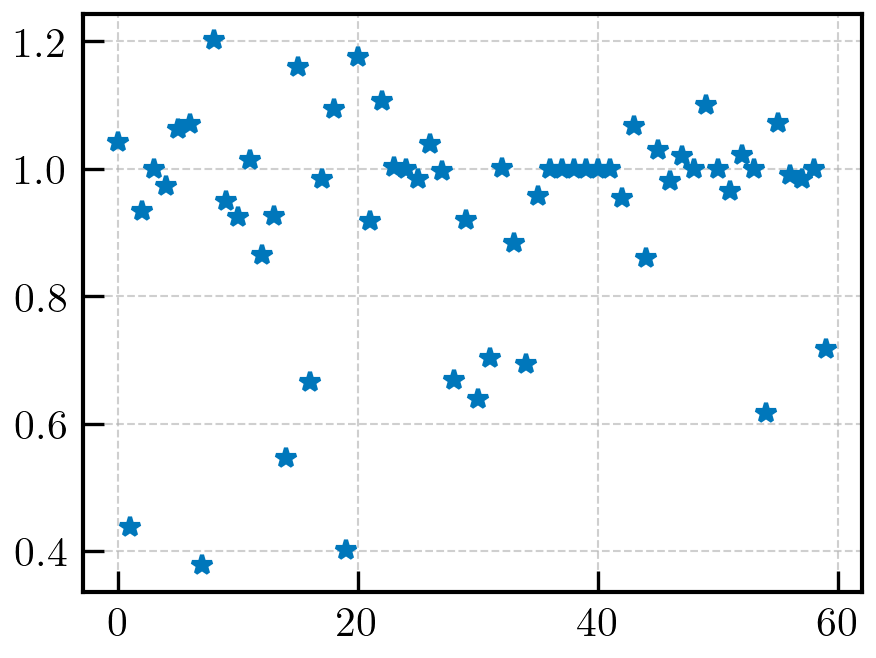

In [116]:
plt.plot(pmt_gain_in_ring, '*');

## Correlation with the gains

In [93]:
dbpmt = pd.read_hdf(filenames[0], "/DB/DataPMT")
dbpmt.head()

,SensorID,ChannelID,PmtID,Active,X,Y,coeff_blr,coeff_c,adc_to_pes,noise_rms,Sigma
0,0,100,PMTR11410,1,128.7,6.400,0.000558,3.403945e-07,33.6135,0,15.1408
1,1,101,PMTR11410,1,66.2,114.653,0.000564,2.844508e-07,28.1312,0,11.0785
2,2,102,PMTR11410,1,-58.8,114.653,0.000564,2.597524e-07,37.2036,0,15.9988
3,3,103,PMTR11410,0,-121.3,6.400,0.000561,3.982968e-07,0.0000,0,0.0000
4,4,104,PMTR11410,1,-58.8,-101.853,0.000565,2.423053e-07,42.4011,0,22.2532


In [94]:
pmt_gain  = dbpmt.adc_to_pes.values
pmt_sigma = dbpmt.Sigma.values

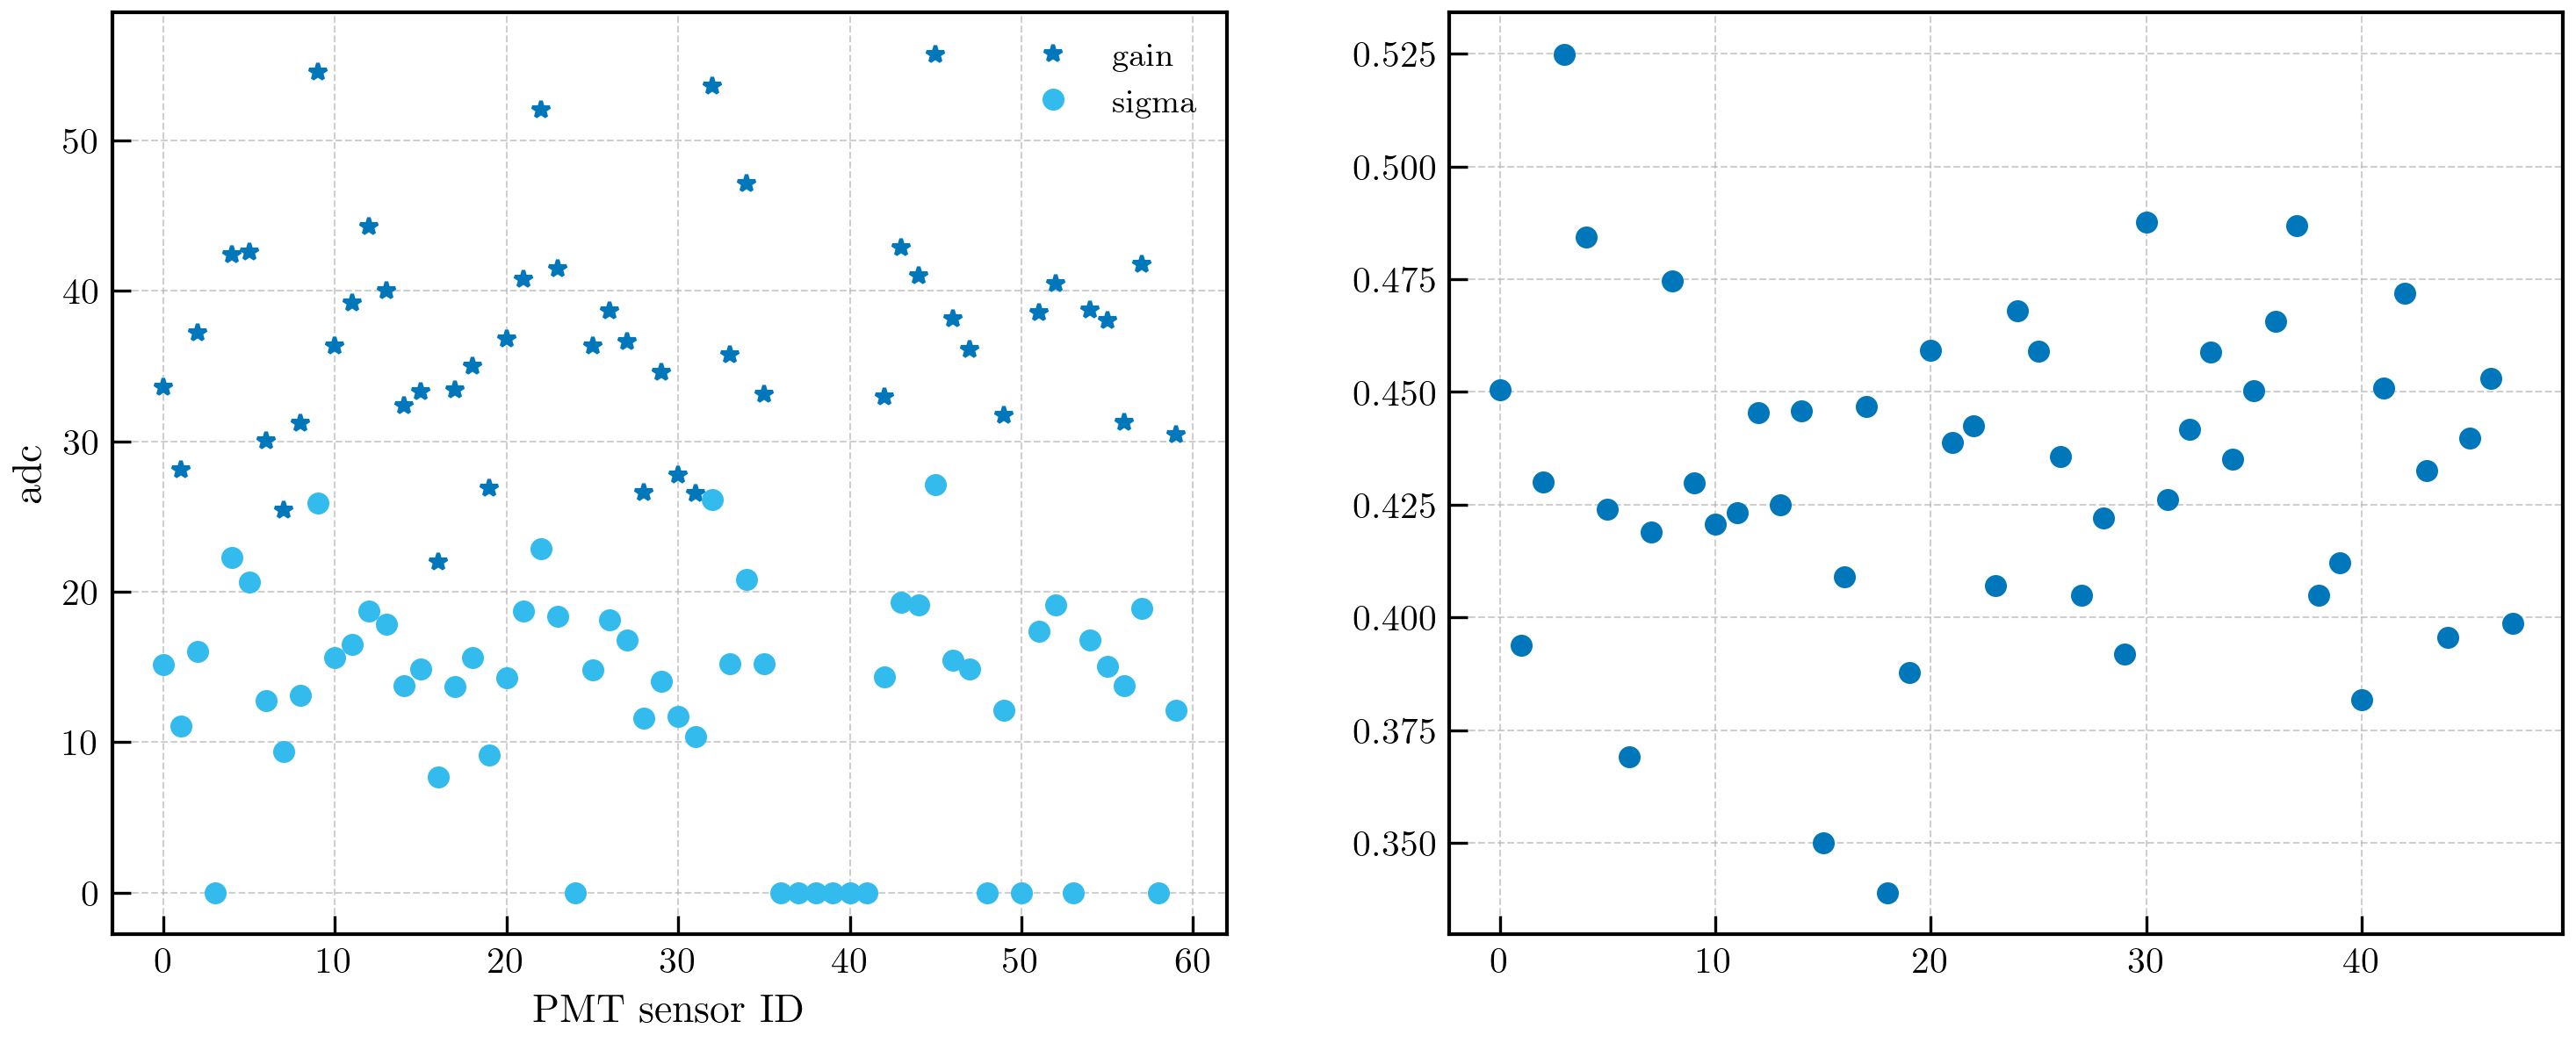

In [117]:
cv = pltext.canvas(4, 2);
cv(1); plt.plot(pmt_gain, '*', label = 'gain'); plt.plot(pmt_sigma, 'o', label = 'sigma'); 
plt.xlabel('PMT sensor ID'); plt.ylabel('adc'); plt.legend();
pmt_on = pmt_sigma > 0
cv(2); plt.plot(pmt_sigma[pmt_on]/pmt_gain[pmt_on], 'o');

In [123]:
dbpmt.X.values

array([ 128.7    ,   66.2    ,  -58.8    , -121.3    ,  -58.8    ,
         66.2    ,  253.7    ,  128.7    , -121.3    , -246.3    ,
       -121.3    ,  128.7    ,  191.2    ,    3.65945, -183.841  ,
       -183.8    ,    3.74055,  191.241  ,  378.7    ,  191.2    ,
       -183.8    , -371.3    , -183.8    ,  191.2    ,  316.2    ,
         66.1594 , -246.341  , -308.8    ,  -58.7594 ,  253.741  ,
        253.7    ,  -58.8811 , -308.881  , -246.3    ,   66.2811 ,
        316.281  ,  503.7    ,  253.7    , -246.3    , -496.3    ,
       -246.3    ,  253.7    ,  441.2    ,  128.659  , -308.841  ,
       -433.8    , -121.259  ,  316.241  ,  378.7    ,    3.6189 ,
       -371.381  , -371.3    ,    3.7811 ,  378.781  ,  316.2    ,
       -121.422  , -433.922  , -308.8    ,  128.822  ,  441.322  ])

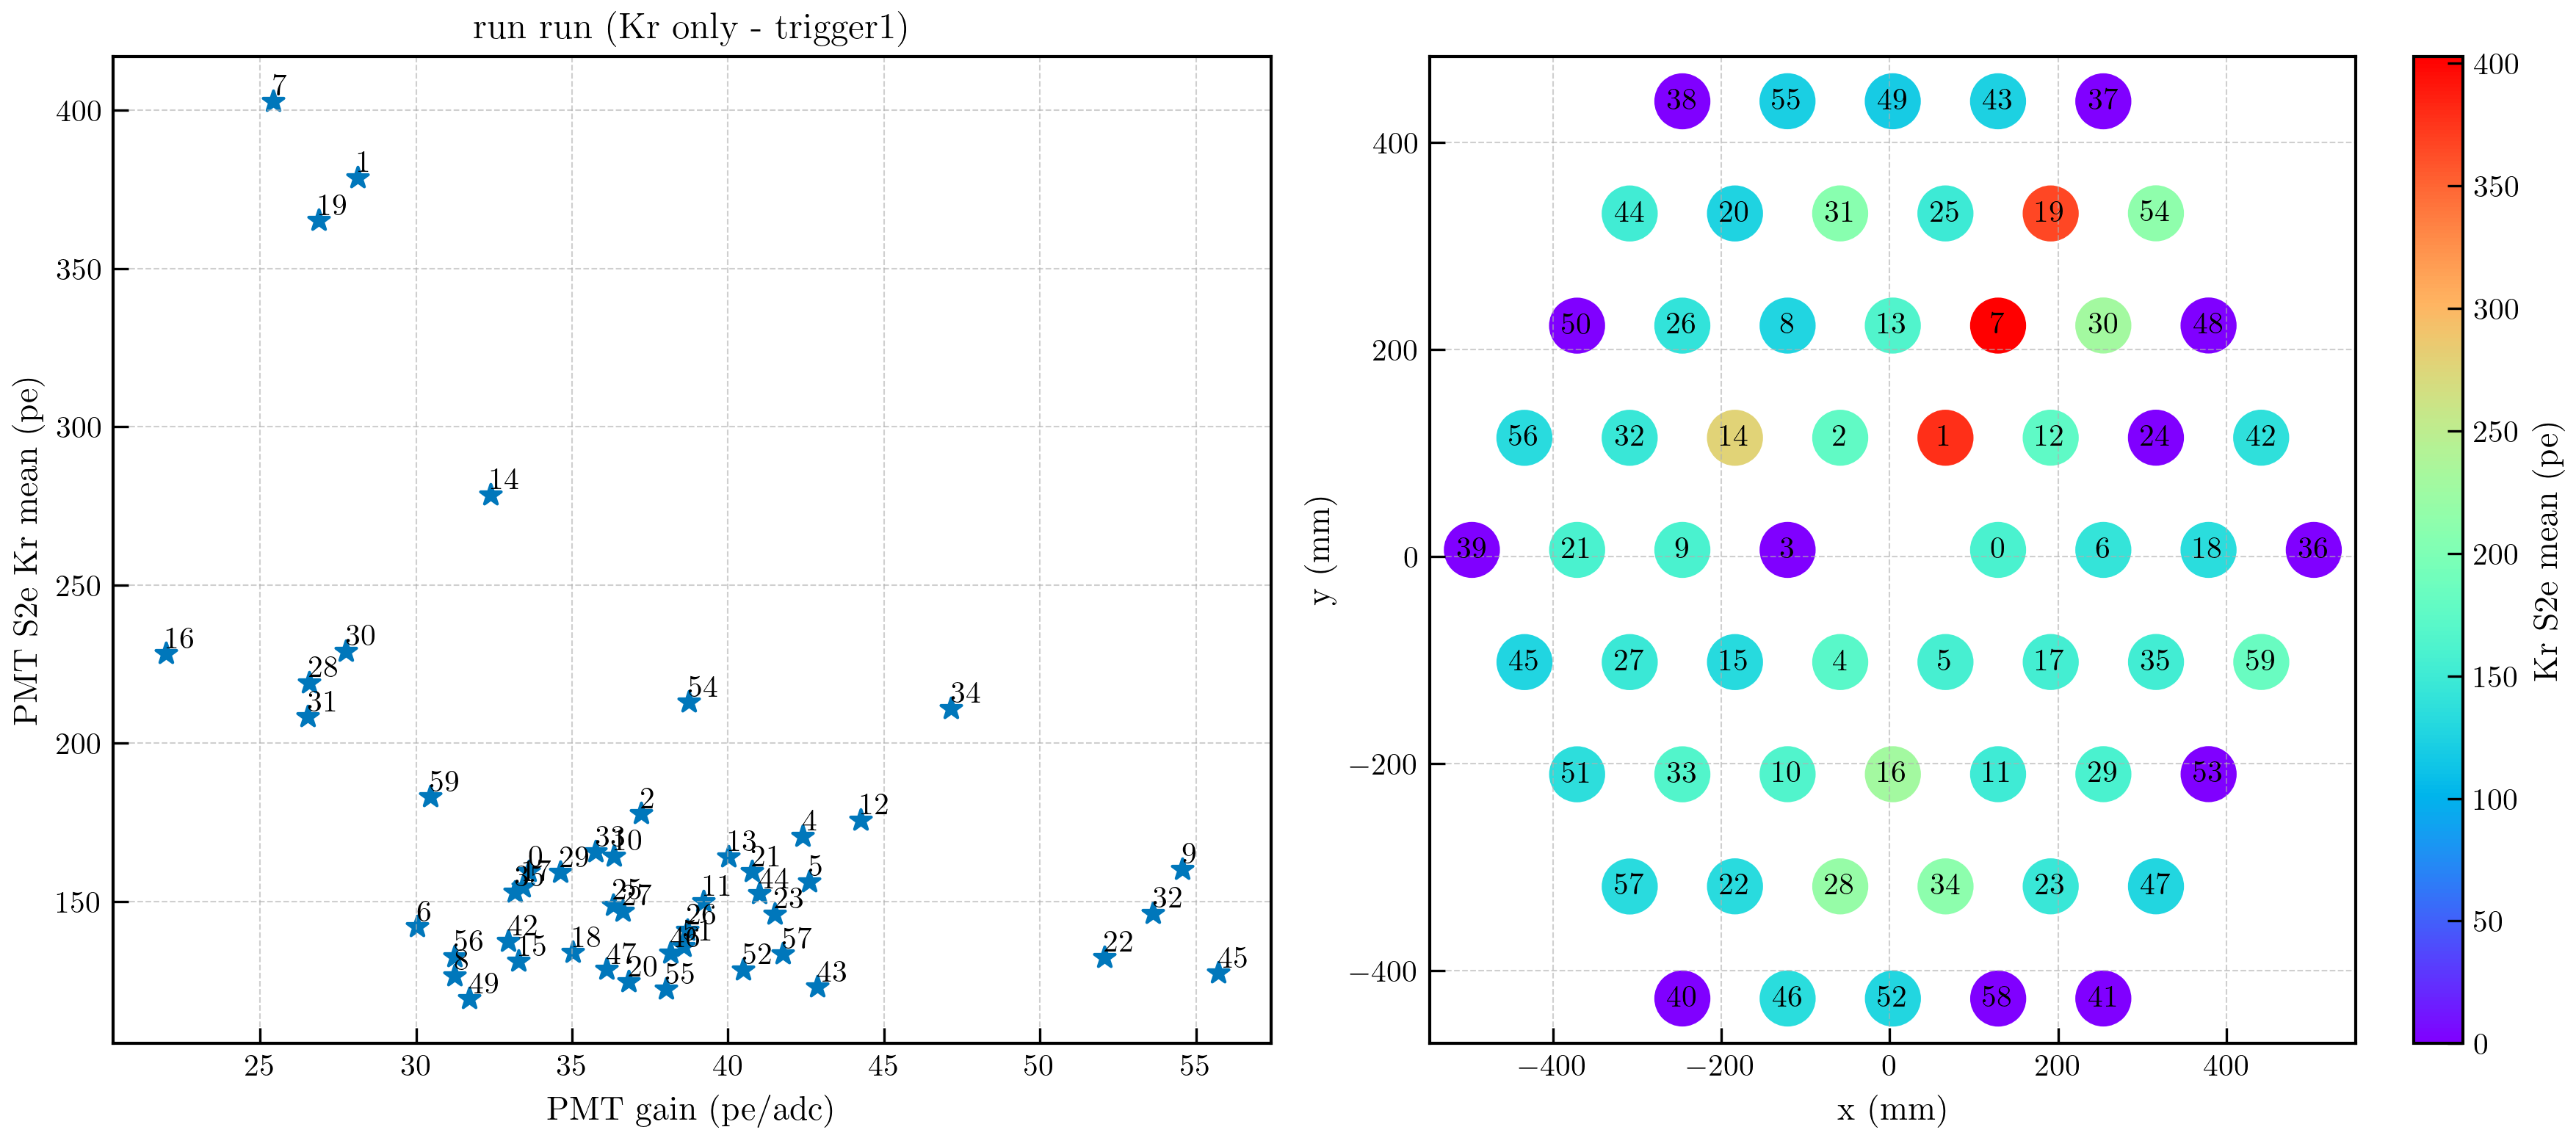

In [145]:
cv = pltext.canvas(4, 2); 
cv(1); plt.scatter(pmt_gain[pmt_on], pmt_mean[pmt_on], marker = '*', s = 50); 
plt.xlabel('PMT gain (pe/adc)'); plt.ylabel("PMT S2e Kr mean (pe)")
for id in range(60):
    xi, yi, li = pmt_gain[id], pmt_mean[id], str(id)
    if (pmt_on[id]):
        plt.text(xi, yi, li, fontsize=10, ha='left', va='bottom')
    plt.title("run {run} (Kr only - trigger1)")

cv(2);  xi, yi = dbpmt.X.values, dbpmt.Y.values
plt.scatter(xi, yi, c = pmt_mean, s = 300); cb_ = plt.colorbar(); cb_.set_label("Kr S2e mean (pe)")
plt.xlabel('x (mm)'); plt.ylabel("y (mm)");
for i in range(60):     
    plt.text(xi[i], yi[i], str(i), fontsize=10, ha='center', va='center')

plt.tight_layout();

In [37]:
pmtsum_ = df.groupby("event npmt".split()).sum()

In [38]:
pmtsum_

peak         ene
event   npmt                  
66761   0        0  146.469070
        1        0  354.282227
        2        0  184.786362
        4        0  160.292786
        5        0  143.316681
...            ...         ...
2760410 54       0  224.972748
        55       0  109.889038
        56       0  120.302307
        57       0  149.564911
        59       0  171.581253

[604752 rows x 2 columns]

In [39]:
evts_0 = pmtsum_.xs(0, level = "npmt").index.values

In [40]:
kdst_sorted = kdst.sort_values(by="event").reset_index(drop=True)
kdst_events = kdst_sorted.event.unique()

In [41]:
kdst.columns

Index(['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h',
       'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'qmax', 'Nsipm', 'DT',
       'Z', 'Zrms', 'X', 'Y', 'R', 'Phi', 'Xrms', 'Yrms', 'd2band',
       'abs_d2band', 'DTguess'],
      dtype='object')

In [42]:
np.all(evts_0 ==  kdst_events)

/var/folders/56/_pmdccc97ljb_l3v3s6gkrxm0000gn/T/ipykernel_7033/3046187493.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  np.all(evts_0 ==  kdst_events)


False

### Get the S2 vs DT per MPT

ValueError: x and y must be the same size

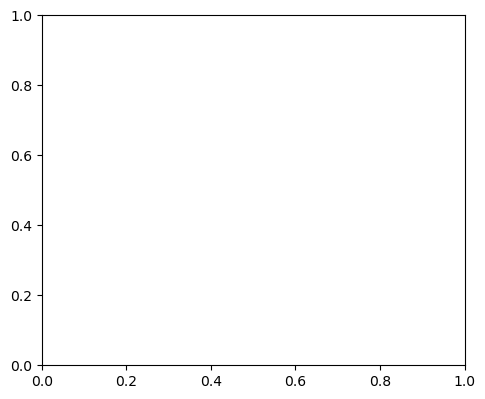

In [43]:
cv = pltext.canvas(4, 2)
for iring in range(4):
    cv(iring + 1)
    dt = kdst_sorted.DT
    for i in pmt_rings[iring]:
        if i not in pmt_index: continue
        s2e = pmtsum_.xs(i, level = "npmt")["ene"].values
        plt.scatter(dt, s2e, alpha = 0.02, label = f"PMT {i}");
    plt.xlabel("drift time ($\mu$s)"); plt.ylabel("S2e (pe)"); plt.title(f"ring {iring}");
plt.legend(); plt.tight_layout();


In [44]:
df   = pmap.s2_pmt
pmttot = df.groupby("event".split()).sum()

In [45]:
kdst_sorted.columns

Index(['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h',
       'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'qmax', 'Nsipm', 'DT',
       'Z', 'Zrms', 'X', 'Y', 'R', 'Phi', 'Xrms', 'Yrms', 'd2band',
       'abs_d2band', 'DTguess'],
      dtype='object')

ValueError: x and y must be the same size

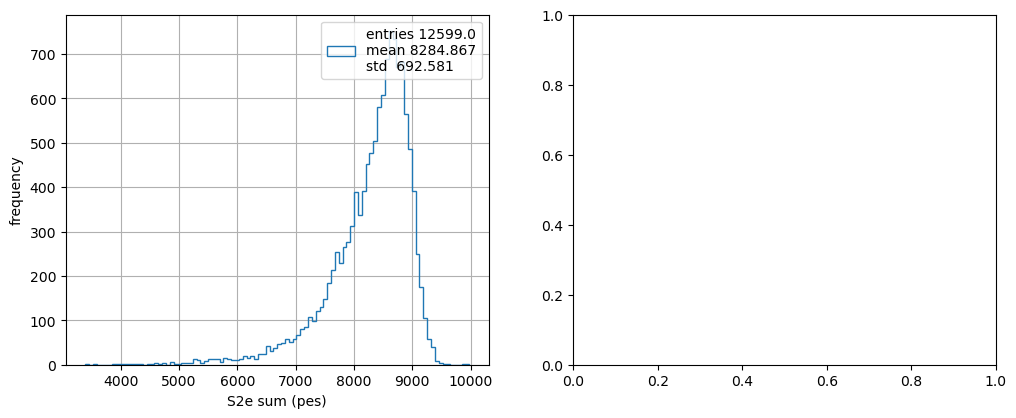

In [46]:
s2etot = pmttot["ene"].values
dt    = kdst_sorted["DT"].values

cv = pltext.canvas(4, 2)
cv(1); pltext.hist(s2etot, 100); plt.xlabel("S2e sum (pes)"); plt.ylabel("frequency");
cv(2); plt.scatter(dt, s2etot, alpha = 0.01);
plt.xlabel("drift time ($\mu$s)"); plt.ylabel("S2e (pe)"); plt.title(f"run {run}");
cv(3); pltext.hist(kdst_sorted.R, 100); plt.xlabel("R$^2$ (mm$^2$)"); plt.ylabel("frequency");
cv(4); plt.scatter(dt, kdst_sorted.R, alpha = 0.01); plt.xlabel("drift time ($\mu$s)"); plt.ylabel("R$^2$ (mm$^2$)");
plt.tight_layout();


In [126]:
sel_kr       = in_range(s2etot, 7.5e3, 9.5e3)
sel_krcenter = sel_kr & in_range(kdst_sorted.R, 0, 100000)



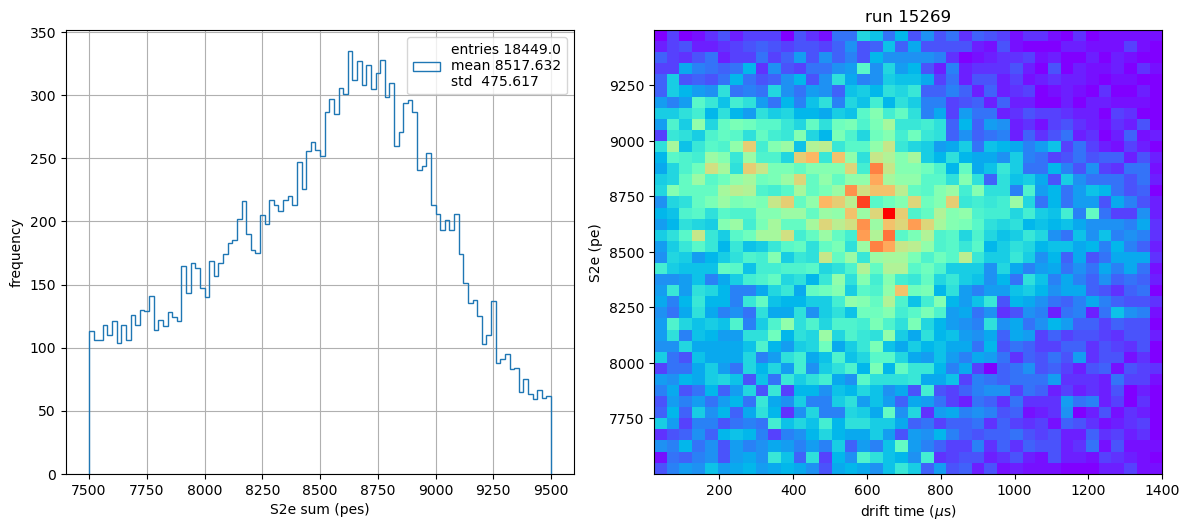

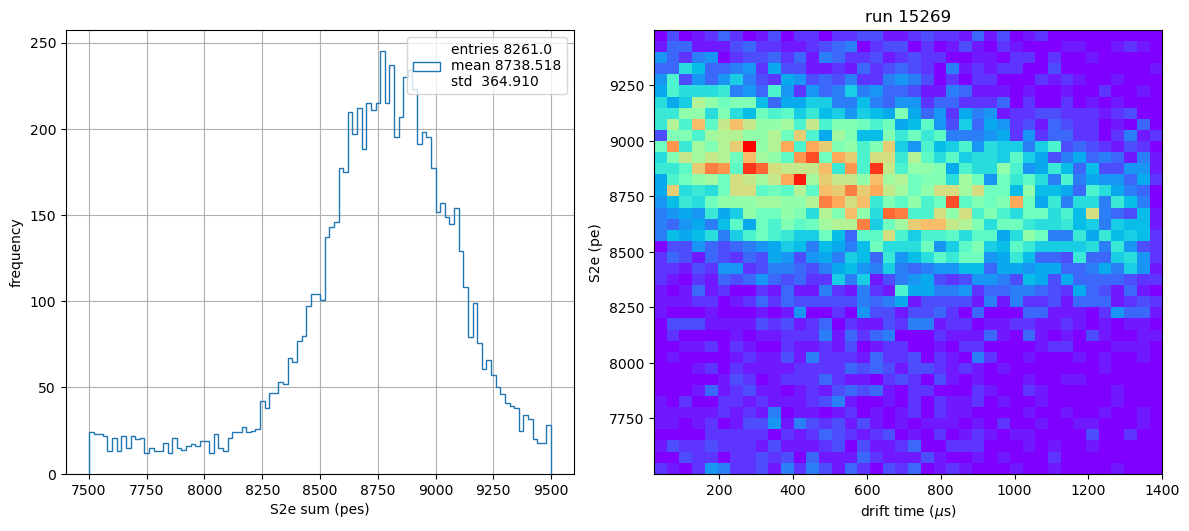

In [128]:
sel = sel_kr
cv = pltext.canvas(4, 2)
cv(1); pltext.hist(s2etot[sel], 100); plt.xlabel("S2e sum (pes)"); plt.ylabel("frequency");
cv(2); plt.hist2d(dt[sel], s2etot[sel], (40, 40));
plt.xlabel("drift time ($\mu$s)"); plt.ylabel("S2e (pe)"); plt.title(f"run {run}");
plt.tight_layout();

sel = sel_krcenter
cv = pltext.canvas(4, 2)
cv(1); pltext.hist(s2etot[sel_pure], 100); plt.xlabel("S2e sum (pes)"); plt.ylabel("frequency");
cv(2); plt.hist2d(dt[sel_pure], s2etot[sel_pure], (40, 40));
plt.xlabel("drift time ($\mu$s)"); plt.ylabel("S2e (pe)"); plt.title(f"run {run}");
plt.tight_layout();

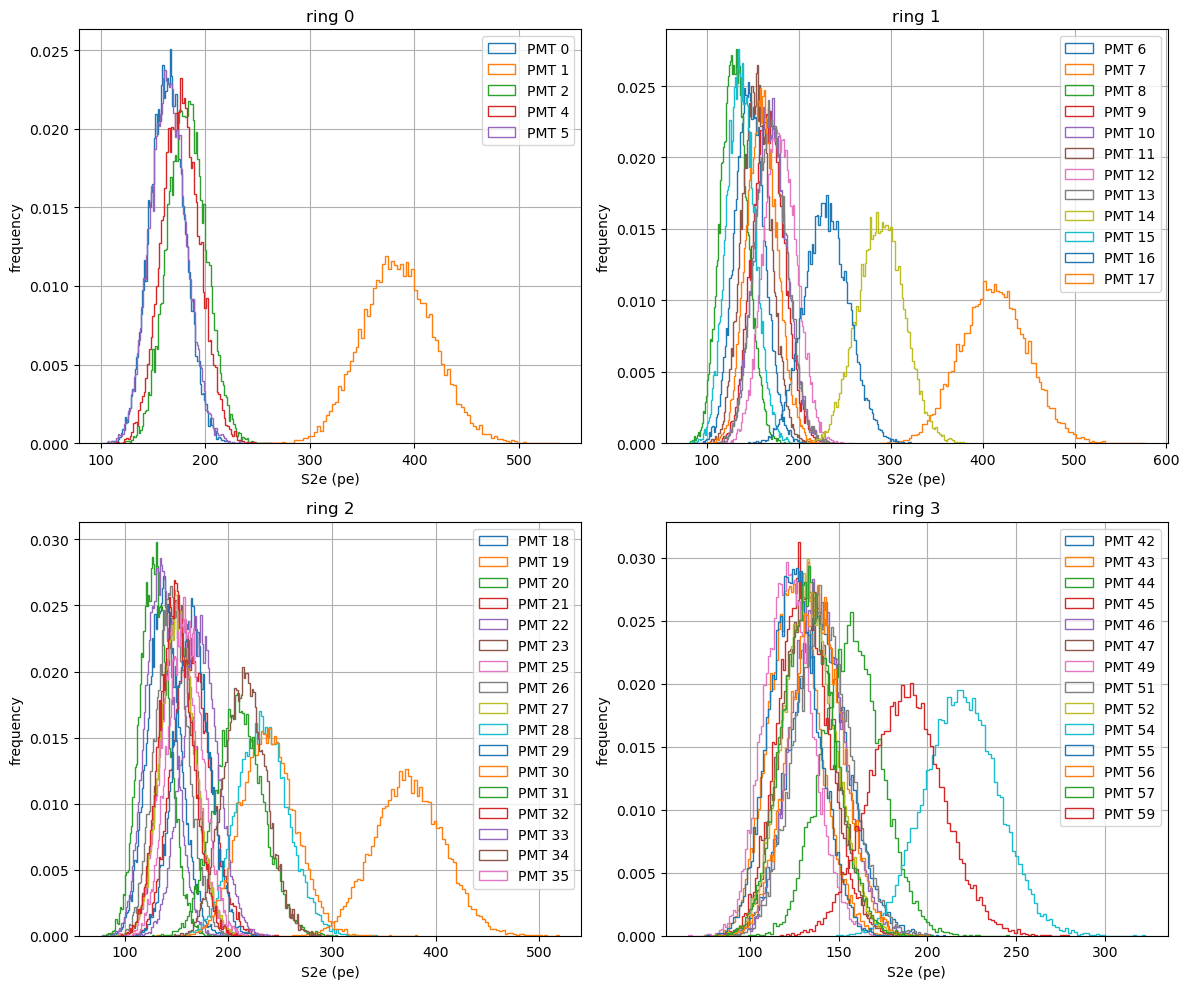

In [130]:
sel = sel_kr

df   = pmap.s2_pmt
pmtsum = df.groupby("event npmt".split())['ene'].sum()

pmt_index = df.npmt.unique()
pmt_rings = [np.arange(0, 6), np.arange(6, 18), np.arange(18, 36), np.arange(36, 60)]
cv = pltext.canvas(4, 2)
for k, ids in enumerate(pmt_rings):
    cv(k+1)
    for i in ids:
        if i not in pmt_index: continue
        pltext.hist(pmtsum.xs(i, level = "npmt")[sel], 100, density = True, stats = False, label = f"PMT {i}");
    plt.xlabel("S2e (pe)"); plt.title(f"ring {k}"); plt.ylabel("frequency");
plt.tight_layout()

In [47]:
isel = sel_krcenter

cv = pltext.canvas(4, 2)
for iring in range(4):
    cv(iring + 1)
    dt = kdst_sorted.DT
    for i in pmt_rings[iring]:
        if i not in pmt_index: continue
        s2e = pmtsum_.xs(i, level = "npmt")["ene"].values
        plt.scatter(dt[sel], s2e[sel], alpha = 0.01, label = f"PMT {i}"); 
    plt.legend(); plt.xlabel("drift time ($\mu$s)"); plt.ylabel("S2e (pe)"); plt.title(f"ring {iring}");



NameError: name 'sel_krcenter' is not defined

In [114]:
#print(pmap[2].event.unique())
print(pmap[3].event.unique())
print(pmap[4].event.unique())


[2699685 2699748 2699853 2699930 2700182 2700273 2700280 1777897 1777974
 1778016 1778205 1778366 1778485 2379365 2379386 2379463 2379491 2379498
 2379575 2379694 2379743 2379750 2379820 2379827 2379848 2379883 2379946
  948880  949083  949139  949223 2144053 2144228 2144235 2144347 2144543
 3002512 3002603 3002631 3002687 3002827 3002862 3002897 3002946 1458774
 1458788 1459026 1459096 2009667 2009688 2009786 2009828 2009912 2009947
 2009961 2010010 2010122 2010255 2578788 2579005 2579201 2579369]
[2699685 2699748 2699853 2699930 2700182 2700273 2700280 1777897 1778016
 1778205 1778485 2379365 2379386 2379463 2379491 2379498 2379575 2379694
 2379743 2379820 2379827 2379848 2379883 2379946  948880  949083  949139
  949223 2144053 2144228 2144235 2144347 2144543 3002512 3002603 3002631
 3002687 3002827 3002862 3002897 1458774 1458788 1459026 1459096 2009667
 2009688 2009786 2009828 2009912 2009947 2009961 2010010 2010122 2010255
 2578788 2579005 2579201 2579369]


In [ ]:
pmap

In [ ]:
def dfs_save(s1, s2, s2)

import pandas as pd

df1.to_hdf('experimentos.h5', key='resultados_temp', mode='a',
           format='table', complevel=9, complib='blosc')

df2.to_hdf('experimentos.h5', key='resultados_presion', mode='a',
           format='table', complevel=9, complib='blosc')

df3.to_hdf('experimentos.h5', key='condiciones_iniciales', mode='a',
           format='table', complevel=9, complib='blosc')


In [ ]:
## reading as pmaps

pmaps = load_pmaps(filename)
evt = pmaps[evt_number]
evt.s1s # una lista de los s1s
evt.s2s # una lista de los s2s